##Lab 8

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
# Column names as per UCI IRIS dataset
columns = [
"sepal_length",
"sepal_width",
"petal_length",
"petal_width",
"species"
]

In [ ]:
# Load the IRIS Dataset (NO HEADER in iris.data)
data = pd.read_csv("/content/Iris.csv", header=None, names=columns)

In [ ]:
# Separate features and target
df = data.drop("species", axis=1)
print("First five rows of dataset:")
print(df.head())

First five rows of dataset:
     sepal_length   sepal_width   petal_length   petal_width
Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
1             5.1           3.5            1.4           0.2
2             4.9           3.0            1.4           0.2
3             4.7           3.2            1.3           0.2
4             4.6           3.1            1.5           0.2


In [ ]:
# Feature Scaling
scaler = StandardScaler()

# The previous loading of 'df' (in cells `lys7KLUy_1TQ` and `sGzTmF8y_4l8`)
# resulted in string values in the DataFrame because the CSV was read
# with header=None, treating the actual header row as data.
# We need to correctly load the dataset and select only the numerical feature columns.

# Re-loading the Iris.csv correctly. Assuming it has a header by default.
# This will correctly read columns: 'Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species'
raw_data = pd.read_csv("/content/Iris.csv")

# Extract only the numerical feature columns (excluding 'Id' and 'Species' as they are not features for clustering).
df_numerical_features = raw_data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# Now, 'df_numerical_features' contains only numerical features and can be scaled.
X_scaled = scaler.fit_transform(df_numerical_features)

In [ ]:
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df = df_numerical_features.copy() # Re-align df to match the length of X_scaled
df['KMeans_Cluster'] = kmeans_labels

In [ ]:
# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("\nK-Means Silhouette Score:", kmeans_silhouette)


K-Means Silhouette Score: 0.4787241921049546


In [ ]:
# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hierarchical_labels

In [ ]:
# Evaluate Hierarchical clustering
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)

Hierarchical Clustering Silhouette Score: 0.44553956399200406


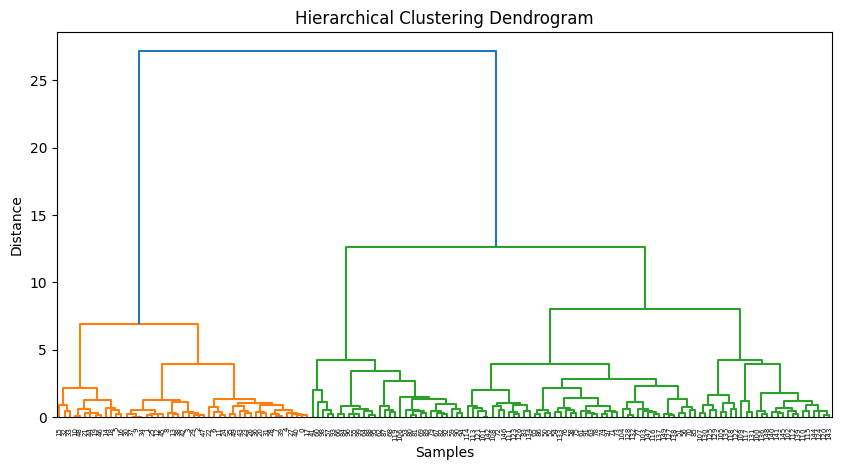

In [ ]:
# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
# Visualization of Clusters
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Feature 2')

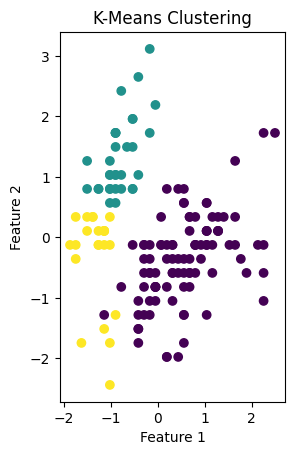

In [ ]:
# KMeans Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0
]
, X_scaled[:,1
]
, c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

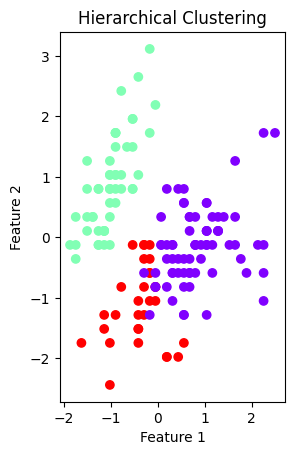

In [ ]:
# Hierarchical Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0],
            X_scaled[:,1],
            c=hierarchical_labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()